# NeuroSegment-BraTS: Treinamento do Modelo (Deep Learning)

**Notebook 4.2:** Modelagem e Experimentação — Swin UNETR

Nesta etapa, instanciamos a arquitetura **Swin UNETR**, definimos os parâmetros de otimização e executamos o ciclo de treinamento.

**Metodologia Experimental:**
*   **Modelo:** Swin UNETR (Swin Transformer como encoder + decoder U-Net). Captura contexto global longo via self-attention hierárquica, diferindo da U-Net 3D que usa apenas convoluções locais.
*   **Função de Perda:** `DiceCELoss`. Combinação de *Cross-Entropy* (classificação geral) com *Dice Loss* (desbalanceamento de classes).
*   **Otimizador:** AdamW (variante do Adam com decaimento de peso separado, recomendado para Transformers).
*   **Gestão de Hardware:** `use_checkpoint=True` para economia de VRAM via gradient checkpointing. Validação via `SlidingWindowInferer`.

## 1. Importações e Inicialização

In [1]:
import optuna
import os
import torch
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import matplotlib.pyplot as plt

# Definindo o dispositivo de aceleração (CUDA/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinamento rodando no dispositivo: {device}")

# Limpeza preventiva do Cache da GPU
if device.type == 'cuda':
    torch.cuda.empty_cache()

# Post-processing para validação: converte logits e labels para one-hot
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

Treinamento rodando no dispositivo: cuda


In [2]:
from tqdm.notebook import tqdm

def train_epoch(model, optimizer, loss_fn, dataloader, device):
    """Treina o modelo por 1 época. Retorna a loss média."""
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in dataloader:
        step += 1
        inputs = batch_data['image'].to(device)
        labels = batch_data['label'].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / step

def validate(model, dataloader, device, roi_size=(96, 96, 96)):
    """Avalia o modelo no conjunto de validação. Retorna o Dice médio."""
    model.eval()
    post_pred = AsDiscrete(argmax=True, to_onehot=4)
    post_label = AsDiscrete(to_onehot=4)
    dice = DiceMetric(include_background=False, reduction='mean')
    with torch.no_grad():
        for val_data in dataloader:
            val_inputs = val_data['image'].to(device)
            val_labels = val_data['label'].to(device)
            val_outputs = sliding_window_inference(
                inputs=val_inputs, roi_size=roi_size, sw_batch_size=4, predictor=model
            )
            val_outputs_list = [post_pred(i) for i in val_outputs]
            val_labels_list = [post_label(i) for i in val_labels]
            dice(y_pred=val_outputs_list, y=val_labels_list)
    result = dice.aggregate().item()
    dice.reset()
    return result

## 2. Ingestão do Pipeline de Dados
Abaixo, conectamos este notebook aos iteradores criados no Notebook 3.

In [3]:
import sys
sys.path.append('../')
from src.data_pipeline import get_dataloaders

# 1. Ingestão do Pipeline
train_loader, val_loader = get_dataloaders()
print("DataLoaders carregados com sucesso no Notebook 4.2!")

# Validando a conexão
test_batch = next(iter(train_loader))
print(f"Shape de entrada da imagem: {test_batch['image'].shape}") 
# Esperado: (Batch, Canais, X, Y, Z) -> ex: (1, 4, 96, 96, 96)

Total de pacientes carregados na tubulação: 368
DataLoaders carregados com sucesso no Notebook 4.2!


/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Shape de entrada da imagem: torch.Size([2, 4, 96, 96, 96])


## 3. Definição da Arquitetura (Swin UNETR) e Hiperparâmetros
Configuramos o Swin UNETR para aceitar 4 canais de entrada (FLAIR, T1, T1ce, T2) e devolver predições para as nossas 4 classes de interesse.

**Diferenciais do Swin UNETR:**
- Usa **Swin Transformer** no encoder: divide o volume em janelas 3D e calcula self-attention localmente, depois desloca as janelas na próxima camada para capturar interações entre regiões distantes.
-  (reduzido do padrão 48) para caber em GPUs com ~12GB VRAM.
-  ativa gradient checkpointing: troca computação por memória, recalculando ativações no backward ao invés de armazená-las.

In [4]:
# 1. O Modelo: Swin UNETR
model = SwinUNETR(
    in_channels=4,               # 4 Modalidades (FLAIR, T1, T1ce, T2)
    out_channels=4,              # 4 Classes de saída (Background, NCR, ED, ET)
    feature_size=12,             # Reduzido de 24 para caber em GPUs com ~12GB VRAM
    use_checkpoint=True,         # Gradient checkpointing: troca memória por computação
).to(device)

# 2. A Função de Perda (Loss Function)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# 3. O Otimizador: AdamW (recomendado para Transformers)
learning_rate = 1e-4
weight_decay = 1e-5
optimizer = torch.optim.AdamW(model.parameters(), learning_rate, weight_decay=weight_decay)

# 4. A Métrica de Avaliação Oficial (Dice Score)
dice_metric = DiceMetric(include_background=False, reduction="mean")

print(f"Modelo Swin UNETR instanciado com {sum(p.numel() for p in model.parameters()):,} parâmetros")

Modelo Swin UNETR instanciado com 4,079,386 parâmetros


## 4. Otimização de Hiperparâmetros com Optuna
Usamos o Optuna para buscar os melhores hiperparâmetros. Cada trial treina por 10 épocas e avalia o Dice na validação.

**Hiperparâmetros buscados (Swin UNETR):**
- `learning_rate`: taxa de aprendizado (escala logarítmica entre 1e-5 e 1e-3)
- `weight_decay`: decaimento de peso (escala logarítmica entre 1e-6 e 1e-3)

In [5]:
import optuna

def objective_swin(trial):
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    model_trial = SwinUNETR(
        in_channels=4, out_channels=4, feature_size=12, use_checkpoint=True,
    ).to(device)

    optimizer_trial = torch.optim.AdamW(model_trial.parameters(), lr=lr, weight_decay=wd)
    loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)

    # DataLoader com num_workers=0 para evitar deadlock no Jupyter
    from monai.data import DataLoader as _MDL
    train_loader_opt = _MDL(train_loader.dataset, batch_size=1, shuffle=True, num_workers=0)
    val_loader_opt = _MDL(val_loader.dataset, batch_size=1, num_workers=0)

    for epoch in range(10):
        loss = train_epoch(model_trial, optimizer_trial, loss_fn, train_loader_opt, device)
        print(f'  Trial {trial.number} | Época {epoch+1}/10 | Loss: {loss:.4f}')

    result = validate(model_trial, val_loader_opt, device)

    del model_trial, optimizer_trial
    del train_loader_opt, val_loader_opt
    torch.cuda.empty_cache()

    return result

study = optuna.create_study(direction='maximize')
study.optimize(objective_swin, n_trials=10, show_progress_bar=True)

[I 2026-05-08 12:12:09,092] A new study created in memory with name: no-name-b54f6c9d-49c8-4068-90f7-08bfad7fc935
  0%|          | 0/10 [00:00<?, ?it/s]

  Trial 0 | Época 1/10 | Loss: 1.0013
  Trial 0 | Época 2/10 | Loss: 0.7523
  Trial 0 | Época 3/10 | Loss: 0.6221
  Trial 0 | Época 4/10 | Loss: 0.5072
  Trial 0 | Época 5/10 | Loss: 0.4617
  Trial 0 | Época 6/10 | Loss: 0.4426
  Trial 0 | Época 7/10 | Loss: 0.4294
  Trial 0 | Época 8/10 | Loss: 0.4116
  Trial 0 | Época 9/10 | Loss: 0.3961
  Trial 0 | Época 10/10 | Loss: 0.3870


/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/

[I 2026-05-08 13:05:33,969] Trial 0 finished with value: 0.7347718477249146 and parameters: {'learning_rate': 0.00042107080178661774, 'weight_decay': 6.369631235903379e-05}. Best is trial 0 with value: 0.7347718477249146.
  Trial 1 | Época 1/10 | Loss: 1.5500
  Trial 1 | Época 2/10 | Loss: 0.9356
  Trial 1 | Época 3/10 | Loss: 0.7223
  Trial 1 | Época 4/10 | Loss: 0.6147
  Trial 1 | Época 5/10 | Loss: 0.5447
  Trial 1 | Época 6/10 | Loss: 0.5034
  Trial 1 | Época 7/10 | Loss: 0.4761
  Trial 1 | Época 8/10 | Loss: 0.4459
  Trial 1 | Época 9/10 | Loss: 0.4319
  Trial 1 | Época 10/10 | Loss: 0.4135


Best trial: 1. Best value: 0.73839:  20%|██        | 2/10 [1:48:01<7:12:54, 3246.83s/it] 

...

[I 2026-05-08 19:52:17,631] Trial 7 finished with value: 0.4550932049751282 and parameters: {'learning_rate': 1.2478787403327117e-05, 'weight_decay': 1.4686041477651335e-06}. Best is trial 5 with value: 0.7426802515983582.
  Trial 8 | Época 1/10 | Loss: 1.9671
  Trial 8 | Época 2/10 | Loss: 1.5851
  Trial 8 | Época 3/10 | Loss: 1.3405
  Trial 8 | Época 4/10 | Loss: 1.1641
  Trial 8 | Época 5/10 | Loss: 1.0264
  Trial 8 | Época 6/10 | Loss: 0.9251
  Trial 8 | Época 7/10 | Loss: 0.8442
  Trial 8 | Época 8/10 | Loss: 0.7741
  Trial 8 | Época 9/10 | Loss: 0.7207
  Trial 8 | Época 10/10 | Loss: 0.6731


Best trial: 5. Best value: 0.74268:  90%|█████████ | 9/10 [8:36:30<57:40, 3460.25s/it]  

[I 2026-05-08 20:48:39,438] Trial 8 finished with value: 0.6862263083457947 and parameters: {'learning_rate': 7.767289299655502e-05, 'weight_decay': 1.88976212387627e-06}. Best is trial 5 with value: 0.7426802515983582.
  Trial 9 | Época 1/10 | Loss: 1.5753
  Trial 9 | Época 2/10 | Loss: 0.9655
  Trial 9 | Época 3/10 | Loss: 0.7427
  Trial 9 | Época 4/10 | Loss: 0.6285
  Trial 9 | Época 5/10 | Loss: 0.5575
  Trial 9 | Época 6/10 | Loss: 0.5140
  Trial 9 | Época 7/10 | Loss: 0.4821
  Trial 9 | Época 8/10 | Loss: 0.4533
  Trial 9 | Época 9/10 | Loss: 0.4356
  Trial 9 | Época 10/10 | Loss: 0.4177


Best trial: 5. Best value: 0.74268: 100%|██████████| 10/10 [9:41:15<00:00, 3487.50s/it]

[I 2026-05-08 21:53:24,098] Trial 9 finished with value: 0.7354215383529663 and parameters: {'learning_rate': 0.0002871999076009662, 'weight_decay': 5.362941206247459e-06}. Best is trial 5 with value: 0.7426802515983582.


/tmp/ipykernel_52693/3012133766.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis_plot.plot_optimization_history(study)


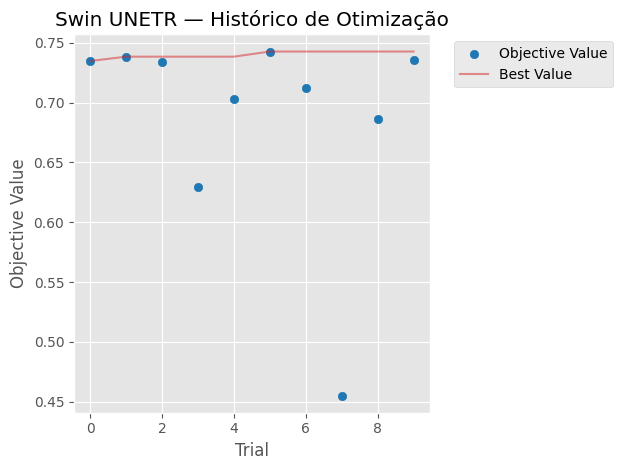

/tmp/ipykernel_52693/3012133766.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = vis_plot.plot_param_importances(study)


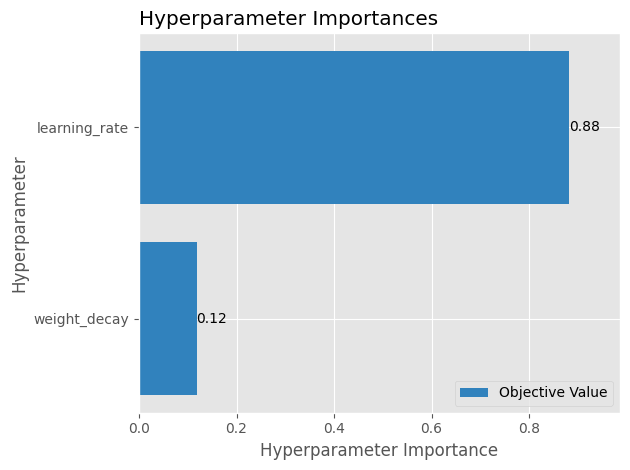

Melhores hiperparâmetros (Swin UNETR):
  learning_rate: 0.000733
  weight_decay: 0.000028
  Dice Score: 0.7427


In [7]:
import optuna.visualization.matplotlib as vis_plot

ax = vis_plot.plot_optimization_history(study)
ax.set_title('Swin UNETR — Histórico de Otimização')
plt.tight_layout()
plt.show()

ax2 = vis_plot.plot_param_importances(study)
plt.tight_layout()
plt.show()

print('=' * 50)
print('Melhores hiperparâmetros (Swin UNETR):')
print('=' * 50)
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f'  {key}: {value:.6f}')
    else:
        print(f'  {key}: {value}')
print(f'  Dice Score: {study.best_value:.4f}')
print('=' * 50)

In [ ]:
# Redefinir modelo e otimizador com os melhores hiperparâmetros
learning_rate = study.best_params['learning_rate']
weight_decay = study.best_params['weight_decay']

model = SwinUNETR(
    in_channels=4, out_channels=4, feature_size=12, use_checkpoint=True,
).to(device)

loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.AdamW(model.parameters(), learning_rate, weight_decay=weight_decay)
dice_metric = DiceMetric(include_background=False, reduction='mean')

print(f'Swin UNETR redefinido com lr={learning_rate:.6f}, weight_decay={weight_decay:.6f}')

Swin UNETR redefinido com lr=0.000733, weight_decay=0.000028


## 4. O Ciclo de Treinamento e Validação
Executamos o treinamento iterativo. A cada *batch*, o modelo tenta segmentar o tumor, calcula o erro e ajusta seus pesos. Ao final de cada época, rodamos uma etapa de validação (sem aprender) para medir a performance real.

In [6]:
from tqdm.notebook import tqdm
# Configurações do Loop
max_epochs = 100
val_interval = 4

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

print('INICIANDO O TREINAMENTO (Swin UNETR)...')

for epoch in tqdm(range(max_epochs), desc='Treinamento Swin UNETR'):
    epoch_loss = train_epoch(model, optimizer, loss_function, train_loader, device)
    epoch_loss_values.append(epoch_loss)

    if (epoch + 1) % val_interval == 0:
        metric = validate(model, val_loader, device)
        metric_values.append(metric)
        print(f'\n>>> Época {epoch+1}/{max_epochs} | Loss: {epoch_loss:.4f} | Dice: {metric:.4f}')

        if metric > best_metric:
            best_metric = metric
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join('../models', 'best_metric_model_swin_unetr.pth'))
            print('Novo recorde! Modelo salvo no disco.')

print(f'\nTREINAMENTO CONCLUÍDO! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}')

INICIANDO O TREINAMENTO (Swin UNETR)...


Treinamento Swin UNETR:   0%|          | 0/100 [00:00<?, ?it/s]

/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/


>>> Época 4/100 | Loss: 0.4712 | Dice: 0.6649
Novo recorde! Modelo salvo no disco.

>>> Época 8/100 | Loss: 0.4082 | Dice: 0.7266
Novo recorde! Modelo salvo no disco.

>>> Época 12/100 | Loss: 0.3762 | Dice: 0.7340
Novo recorde! Modelo salvo no disco.

>>> Época 16/100 | Loss: 0.3522 | Dice: 0.7444
Novo recorde! Modelo salvo no disco.

>>> Época 20/100 | Loss: 0.3492 | Dice: 0.7549
Novo recorde! Modelo salvo no disco.

>>> Época 24/100 | Loss: 0.3354 | Dice: 0.7670
Novo recorde! Modelo salvo no disco.

>>> Época 28/100 | Loss: 0.3327 | Dice: 0.7812
Novo recorde! Modelo salvo no disco.

>>> Época 32/100 | Loss: 0.3155 | Dice: 0.7608

>>> Época 36/100 | Loss: 0.3128 | Dice: 0.7660

>>> Época 40/100 | Loss: 0.3183 | Dice: 0.7438

>>> Época 44/100 | Loss: 0.3066 | Dice: 0.7664

>>> Época 48/100 | Loss: 0.3095 | Dice: 0.7961
Novo recorde! Modelo salvo no disco.

>>> Época 52/100 | Loss: 0.3044 | Dice: 0.7756

>>> Época 56/100 | Loss: 0.2978 | Dice: 0.7678

>>> Época 60/100 | Loss: 0.2998 |

## 5. Curvas de Aprendizado
Visualização da evolução do loss de treino e do Dice de validação ao longo das épocas.

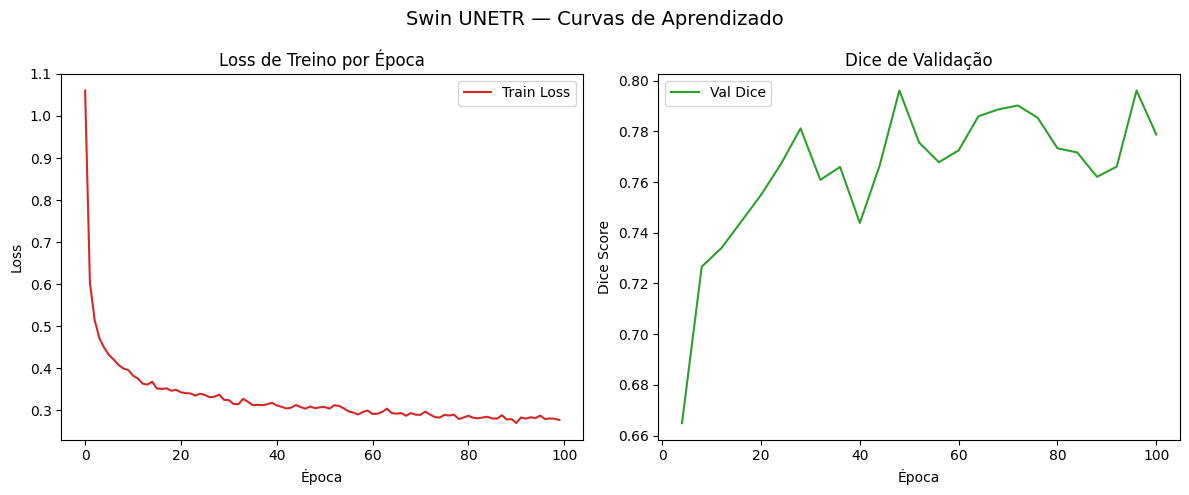

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Curva de Loss de Treino
ax1.plot(epoch_loss_values, label='Train Loss', color='tab:red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Loss de Treino por Época')
ax1.legend()

# Curva de Dice de Validação
val_epochs = [i * val_interval for i in range(1, len(metric_values) + 1)]
ax2.plot(val_epochs, metric_values, label='Val Dice', color='tab:green')
ax2.set_xlabel('Época')
ax2.set_ylabel('Dice Score')
ax2.set_title('Dice de Validação')
ax2.legend()

plt.suptitle('Swin UNETR — Curvas de Aprendizado', fontsize=14)
plt.tight_layout()
plt.savefig('../models/swin_unetr_learning_curves.png', dpi=150)
plt.show()

## 6. Avaliação Detalhada do Melhor Modelo
Carregamos o melhor checkpoint e calculamos métricas detalhadas por classe na base de validação:
- **Dice Score** por classe (NCR, ED, ET)
- **Hausdorff Distance 95** por classe (métrica oficial BraTS)
- **Sensitivity** e **Specificity** por classe

| Métrica | O que mede | Interpretação |
|---------|-----------|---------------|
| **Dice** | Sobreposição entre predição e gabarito | 0–1, maior = melhor |
| **HD95** | Hausdorff Distance 95th percentile — pior distância de fronteira | mm, menor = melhor |
| **Sensitivity** | % de voxels tumorais corretamente detectados | 0–1, maior = melhor |
| **Specificity** | % de voxels saudáveis corretamente identificados | 0–1, maior = melhor |


In [8]:
from monai.metrics import DiceMetric, HausdorffDistanceMetric, ConfusionMatrixMetric

# Carregar o melhor modelo salvo
best_model = SwinUNETR(
    in_channels=4,
    out_channels=4,
    feature_size=12,
    use_checkpoint=True,
).to(device)
best_model.load_state_dict(torch.load(os.path.join('../models', 'best_metric_model_swin_unetr.pth'), weights_only=True))
print('Modelo Swin UNETR carregado com sucesso!')
best_model.eval()

# Métricas por classe
dice_per_class = DiceMetric(include_background=False, reduction="mean_batch")
hd95_per_class = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean_batch")
sensitivity_metric = ConfusionMatrixMetric(include_background=False, metric_name='sensitivity', reduction='mean_batch')
specificity_metric = ConfusionMatrixMetric(include_background=False, metric_name='specificity', reduction='mean_batch')

post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data['image'].to(device)
        val_labels = val_data['label'].to(device)
        
        val_outputs = sliding_window_inference(
            inputs=val_inputs, roi_size=(96, 96, 96), sw_batch_size=1, predictor=best_model
        )
        
        val_outputs_list = [post_pred(i) for i in val_outputs]
        val_labels_list = [post_label(i) for i in val_labels]
        
        dice_per_class(y_pred=val_outputs_list, y=val_labels_list)
        hd95_per_class(y_pred=val_outputs_list, y=val_labels_list)
        sensitivity_metric(y_pred=val_outputs_list, y=val_labels_list)
        specificity_metric(y_pred=val_outputs_list, y=val_labels_list)

# Agregar resultados — ConfusionMatrixMetric retorna lista de tensores
# Agregar resultados
dice_scores = dice_per_class.aggregate()
hd95_scores = hd95_per_class.aggregate()
sens_raw = sensitivity_metric.aggregate()
spec_raw = specificity_metric.aggregate()

# ConfusionMatrixMetric com mean_batch retorna lista de tensores (cada um com C elementos)
# Flatten para 1D: ex: [tensor([a,b,c])] -> tensor([a,b,c])
def to_1d(x):
    if isinstance(x, list):
        x = torch.cat([t.flatten() for t in x])
    if isinstance(x, torch.Tensor) and x.dim() > 1:
        x = x.flatten()
    return x

sens_scores = to_1d(sens_raw)
spec_scores = to_1d(spec_raw)

class_names = ['NCR (TC)', 'ED (WT)', 'ET']
header = '{:<12} {:>8} {:>10} {:>8} {:>8}'.format('Classe', 'Dice', 'HD95', 'Sens', 'Spec')
print(header)
print('-' * 50)
for i, name in enumerate(class_names):
    d = dice_scores[i].item() if hasattr(dice_scores[i], 'item') else float(dice_scores[i])
    h = hd95_scores[i].item() if hasattr(hd95_scores[i], 'item') else float(hd95_scores[i])
    s = sens_scores[i].item() if i < len(sens_scores) else 0.0
    sp = spec_scores[i].item() if i < len(spec_scores) else 0.0
    print('{:<12} {:>8.4f} {:>10.2f} {:>8.4f} {:>8.4f}'.format(name, d, h, s, sp))
print('-' * 50)
mean_dice = dice_scores.mean().item() if hasattr(dice_scores, 'mean') else float(dice_scores)
mean_hd95 = hd95_scores.mean().item() if hasattr(hd95_scores, 'mean') else float(hd95_scores)
print('{:<12} {:>8.4f} {:>10.2f}'.format('Média', mean_dice, mean_hd95))

Modelo Swin UNETR carregado com sucesso!


/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/home/multimegaman/miniconda3/envs/tests/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/home/multimegaman/miniconda3/envs/tests/

Classe           Dice       HD95     Sens     Spec
--------------------------------------------------
NCR (TC)       0.7293      10.74   0.8031   0.9983
ED (WT)        0.8166       8.62   0.8570   0.9967
ET             0.8544       7.26   0.8790   0.9996
--------------------------------------------------
Média          0.8001       8.88
